In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import AutoMinorLocator


/tmp/ipykernel_21283/2270473504.py:39: RuntimeWarning: divide by zero encountered in log
  G = -8.314 * temperature * np.log(H) / 1000


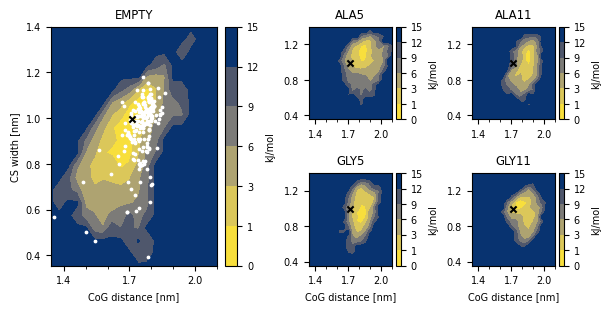

In [11]:
plt.rcParams.update({"font.size": 7})

def getPlottingData(mol, width_range, dist_range, bins):

    # initialize containers
    widths = []
    dists = []

    # read data from all trajectories
    for tid in range(8):
        fname_w = f"../output_files/cs_width/{mol.lower()}.{tid}.dat"
        fname_d = f"../output_files/cog_dist/{mol.lower()}.{tid}.dat"

        # read files
        data_w = np.loadtxt(fname_w)
        data_d = np.loadtxt(fname_d)
        
        # take only latter portions
        start = int(len(data_w) * 0.33)
        widths.append(data_w[start:, 1])
        dists.append(data_d[start:, 1])
    
    # convert to nm
    widths = np.ravel(widths) / 10
    dists = np.ravel(dists) / 10
    
    # get 2D histogram
    H, xedges, yedges = np.histogram2d(dists, widths,
                                       bins=bins, range=(dist_range, width_range),
                                       density=True)
    # transform for contourf
    X, Y = np.meshgrid(xedges[1:], yedges[1:])
    
    # comparing scatter and contour plots, H must be transposed to match X, Y
    H = H.T

    # Gibbs energy
    temperature = 310 # K
    G = -8.314 * temperature * np.log(H) / 1000
    G -= np.min(G) # for global minimum G = 0
    G[G == np.inf] = np.unique(G)[-2] # remove the ugly white inf values

    return X, Y, G

# some setup
width_range = [0.3, 1.4] # 1.1
dist_range = [1.3, 2.1] # 0.7
bins = 20
mols = "EMPTY ALA5 ALA11 GLY5 GLY11".split()
n_mols = len(mols)

# experiments
data_d_exp = np.loadtxt("../output_files/cog_dist/experiment.dat", usecols=1)
data_w_exp = np.loadtxt("../output_files/cs_width/experiment.dat", usecols=1)
dists_exp = data_d_exp / 10
widths_exp = data_w_exp / 10

# initialize figure

fig = plt.figure(layout="constrained", figsize=(6,3))

gs = GridSpec(2, 4, figure=fig)
ax1 = fig.add_subplot(gs[0:2, 0:2])
ax2 = fig.add_subplot(gs[0, 2])
ax3 = fig.add_subplot(gs[0, 3])
ax4 = fig.add_subplot(gs[1, 2])
ax5 = fig.add_subplot(gs[1, 3])

axs = [ax1, ax2, ax3, ax4, ax5]
#fig, axs = plt.subplots(ncols=n_mols, nrows=1, sharex=True, sharey=True,
#                        figsize=((dist_range[1] - dist_range[0]) * 3 * n_mols,
#                                 (width_range[1] - width_range[0]) * 2),
#                        gridspec_kw={"wspace": 0.5})
                                 
for i in range(n_mols):
    
    mol = mols[i]
    ax = axs[i]
    
    X, Y, G = getPlottingData(mol, width_range, dist_range, bins)
    
    # plot sims
    cbar = ax.contourf(X, Y, G, cmap="cividis_r", levels=[0, 1, 3, 6, 9, 12, 15])
    
    # plot exp
    ax.scatter(dists_exp[0], widths_exp[0], color="black", s=20, marker="x", zorder=99)
    
    if i == 0:
        ax.scatter(dists_exp[1:], widths_exp[1:], color="white", s=3, marker="o", zorder=98)
    
    # layout
    if i in [0, 3, 4]:
        ax.set_xlabel("CoG distance [nm]")
    if i == 0:
        ax.set_ylabel("CS width [nm]")
        ax.set_yticks((0.4, 0.6, 0.8, 1.0, 1.2, 1.4))
    else:
        ax.set_yticks((0.4, 0.8, 1.2))
    ax.set_title(mol)
    ax.set_xticks((1.4, 1.7, 2.0))
    ax.xaxis.set_minor_locator(AutoMinorLocator(3))

    plt.colorbar(cbar, label="kJ/mol")

